# Distributions Overview

This notebook gives an overview of the use cases of single-cell data simulation models under different gene distribution assumptions. For spatial transcriptomics data simulation, refer to [spatial transcriptomics example](12-spatial-transcriptomics.ipynb).

We first load the visualization functions for later simulation assessment.

In [1]:
from scdiagnostics import (
    plot_fit_by_covariate,
    plot_sampled_expression_by_covariate,
)

# Negative Binomial

The Negative Binomial (NB) distribution is the default and a common choice for fitting single-cell raw count data with non-negative integer entires. Its overdispersion characteristic allows it to capture additional biological and technical variability that a Poisson distribution (another commonly used distribution for gene expression) cannot. 

In this and next use cases, we will be using the pancreas dataset (referring to [the quickstart](01-quickstart.ipynb) for more information) as an example.

In [2]:
from scdesigner.simulators import NegBinCopula
from scdesigner.datasets import pancreas

example_sce = pancreas()
example_sce

AnnData object with n_obs × n_vars = 2087 × 100
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'cell_type', 'sizeFactor', 'pseudotime'
    var: 'highly_variable_genes'
    uns: 'X_name', 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'counts', 'cpm', 'logcounts', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

`NegBinCopula` allows controlling for the means and dispersions of gene expressions through the `mean_formula` and `dispersion_formula` parameters, and `copula_formula` specifies the gene-gene correlation structure.

In [3]:
sim = NegBinCopula(
    mean_formula = "~ bs(pseudotime, df=10)",
    dispersion_formula = "~ bs(pseudotime, df=3)",
    copula_formula = "~ 1"
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 229/500, Loss: 1.8406, Val Loss: 1.8500


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00,  9.74it/s]


If we want to investigate the coefficients for the fitted models, we can simply call `sim.marginal` and `sim.copula`. 

`sim.marginal` stores the models we fitted on the independent gene expressions, and its `parameter` attribute gives a dictionary of the fitted coefficients for modeling gene means and dispersions.

In [4]:
sim.marginal.parameters['mean']

,Pyy,Iapp,Chgb,Rbp4,Spp1,Chga,Cck,Ins1,Nnat,Ins2,...,Nkx6-1,Fxyd3,Hn1,Smarcd2,Pdia6,Ffar2,Hes6,Serpinh1,Npy,1110012L19Rik
Intercept,0.486613,-1.341395,-0.750541,-0.179812,4.266025,-2.102801,-3.173024,-0.623416,-2.503333,-2.820455,...,0.178312,-0.340200,1.395179,0.016089,1.200146,-4.238821,-0.858509,1.721486,-4.099339,-0.890871
"bs(pseudotime, df=10)[1]",-1.123380,-0.264637,-2.821198,-0.137428,-0.029184,-1.852767,0.807248,-1.514042,1.368478,-0.892993,...,0.482027,0.253204,0.038124,0.072271,-0.043235,4.424599,1.067176,-0.056019,-1.560924,0.191587
"bs(pseudotime, df=10)[2]",-0.371861,0.760043,0.302288,-0.666165,0.010996,1.070239,0.696356,-0.518554,-0.816655,-0.809726,...,-0.430299,-0.466683,-0.499942,0.671399,-0.100423,4.066035,2.311737,-0.479002,0.580323,-0.086199
"bs(pseudotime, df=10)[3]",-1.452262,-0.043677,-4.073937,-1.286438,-1.071017,-3.389012,5.303135,-1.968036,2.635887,-0.245412,...,1.046768,0.234427,0.929680,2.130616,0.132167,4.961374,3.322949,0.296176,-1.595958,0.376720
"bs(pseudotime, df=10)[4]",-0.761217,-0.059867,1.322045,-1.617004,-7.629449,3.694769,7.232867,-0.808832,1.938195,-0.484778,...,1.314312,1.734242,0.489009,1.271496,-1.236764,4.728755,2.121125,-0.907091,-0.732558,2.436293
"bs(pseudotime, df=10)[5]",0.448167,-0.057947,4.641771,1.324314,-4.581512,5.494165,6.424183,-2.153072,2.928240,-1.216249,...,1.130233,1.620811,-0.000789,0.876121,-1.458498,5.975066,1.744356,-1.576188,0.783895,2.474934
"bs(pseudotime, df=10)[6]",3.301443,0.438381,5.002536,2.548978,-6.310517,5.203084,5.418740,-0.750057,0.704906,0.412520,...,1.104639,1.210958,-1.066570,-0.180914,-1.581383,5.396912,1.133063,-2.559644,-3.746213,1.458608
"bs(pseudotime, df=10)[7]",4.011480,3.163963,4.321770,4.144102,-5.207056,5.201315,4.032784,-1.264610,3.690965,0.371162,...,0.912390,1.298826,-1.015807,-1.152730,-0.027772,4.800032,0.794576,-2.560724,3.124479,0.120526
"bs(pseudotime, df=10)[8]",5.270538,7.490810,4.058055,4.146627,-6.572871,4.890687,4.207917,3.463933,5.946340,6.626876,...,1.399944,0.915431,-0.694791,-0.390480,0.497305,4.723429,1.605612,-1.919711,-4.709215,0.114065
"bs(pseudotime, df=10)[9]",4.503641,6.694267,3.601210,4.102409,-5.089272,4.776501,4.079226,5.530558,6.780347,6.637293,...,1.485917,1.039746,-0.954209,-1.328440,1.232054,4.122941,0.667888,-2.509812,8.913049,0.072791


In [5]:
sim.marginal.parameters['dispersion']

,Pyy,Iapp,Chgb,Rbp4,Spp1,Chga,Cck,Ins1,Nnat,Ins2,...,Nkx6-1,Fxyd3,Hn1,Smarcd2,Pdia6,Ffar2,Hes6,Serpinh1,Npy,1110012L19Rik
Intercept,-0.557221,-0.153422,-0.348639,-0.145616,1.503577,-0.000526,0.228073,-0.887780,0.191199,0.400605,...,1.042910,0.311372,0.592191,1.754808,1.779979,0.625336,1.429720,2.117424,-0.849307,0.855785
"bs(pseudotime, df=3)[1]",-0.770811,-0.691453,-1.088739,-1.119117,-1.468734,-1.088874,0.264777,1.150588,-1.717588,-1.737129,...,0.312470,0.024004,1.212165,1.621134,-0.427022,0.192118,0.425993,1.228238,-2.055231,-0.481130
"bs(pseudotime, df=3)[2]",-1.251058,-0.587366,-0.246372,-0.458943,-1.720165,0.673987,-0.172717,-1.243647,-1.371563,-1.515205,...,-1.033538,0.985050,1.334667,0.296272,-0.710573,0.150716,-0.345682,-2.050125,-1.494173,-0.823144
"bs(pseudotime, df=3)[3]",0.604821,1.125710,1.394129,1.572423,-0.721398,0.900835,-0.993711,0.743489,0.593585,0.359393,...,1.031757,-0.471820,1.254887,-0.484429,0.162670,-0.089208,0.523671,-1.744013,-0.385074,0.340276


We can also access the parameters of the copula model by calling `sim.copula.parameters`, which will also give a disctionary. Since we did not assign formula to the copula model while fitting, its `Intercept` element contains the correlations of the genes by default. If we specify categorical variables for the copula formula, the dictionary will contain category-specific correlations across the genes.

In [6]:
sim.copula.parameters['Intercept']

,Pyy,Iapp,Chgb,Rbp4,Spp1,Chga,Cck,Ins1,Nnat,Ins2,...,Nkx6-1,Fxyd3,Hn1,Smarcd2,Pdia6,Ffar2,Hes6,Serpinh1,Npy,1110012L19Rik
Pyy,1.000000,0.060211,-0.105959,0.203226,0.009079,-0.015092,0.089205,-0.003883,-0.020572,-0.045525,...,-0.100681,0.029148,0.038823,0.041561,0.052321,-0.011206,0.007698,0.057137,0.004553,-0.021247
Iapp,0.060211,1.000000,-0.047846,0.045213,0.029453,0.011654,0.068098,0.055171,0.013840,0.061198,...,0.029002,0.026312,0.066936,0.021647,0.003753,0.007218,0.043222,0.006162,0.041837,-0.000565
Chgb,-0.105959,-0.047846,1.000000,-0.082326,0.002115,0.142727,0.066029,-0.009862,0.024481,0.010915,...,0.185055,0.085844,0.049738,-0.001061,0.081635,0.096637,0.056644,0.049664,-0.030894,0.007654
Rbp4,0.203226,0.045213,-0.082326,1.000000,0.025631,-0.018840,0.076176,0.005412,0.038367,-0.006789,...,-0.061679,0.078104,0.046142,0.017550,0.112813,0.011474,0.015198,0.087206,0.022319,0.038721
Spp1,0.009079,0.029453,0.002115,0.025631,1.000000,0.023126,-0.003201,0.037868,0.059296,0.017134,...,0.074990,0.017803,0.031676,0.026055,0.067249,0.042001,0.019059,0.046208,0.006870,0.048941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ffar2,-0.011206,0.007218,0.096637,0.011474,0.042001,0.029729,0.017643,0.015329,-0.007785,0.023572,...,0.047815,0.095125,0.011082,0.030662,0.054569,1.000000,0.039363,-0.008522,-0.022979,0.023621
Hes6,0.007698,0.043222,0.056644,0.015198,0.019059,0.087232,0.043371,0.011638,0.049540,0.040959,...,0.086825,0.033315,0.128392,0.095178,0.060289,0.039363,1.000000,0.075675,-0.044977,0.070286
Serpinh1,0.057137,0.006162,0.049664,0.087206,0.046208,0.021636,0.020241,-0.002432,-0.018448,0.063965,...,0.024232,0.028400,0.086884,0.060498,0.120618,-0.008522,0.075675,1.000000,0.006568,0.071785
Npy,0.004553,0.041837,-0.030894,0.022319,0.006870,0.012580,0.019727,0.020543,0.024624,0.025526,...,-0.019562,-0.052211,0.012418,-0.009133,0.001330,-0.022979,-0.044977,0.006568,1.000000,-0.018909


Checkout [02-simulator-internals](02-simulator-internals.ipynb) for detailed use of the marginal and copula formula and interpretation of the coefficients.


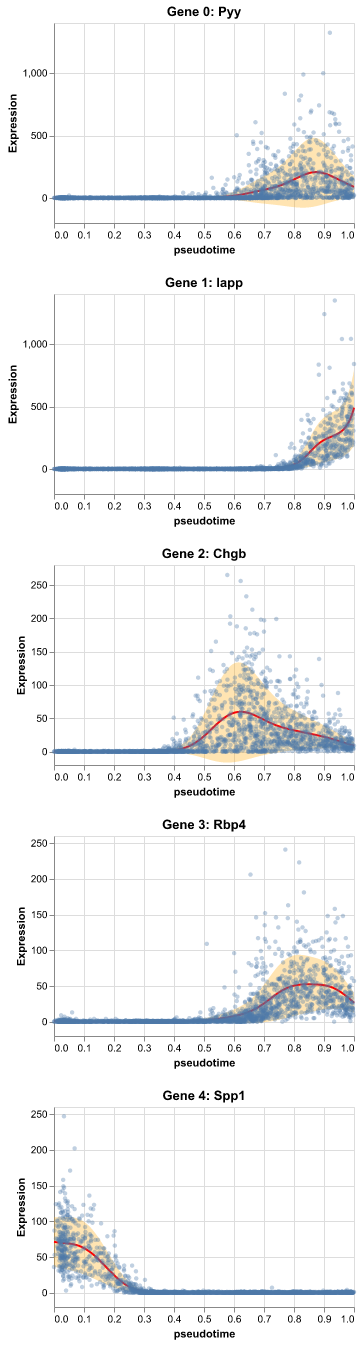

In [7]:
plot_fit_by_covariate(
    sim, 
    example_sce, 
    distribution="negbin",
    covariate="pseudotime",
    num_genes=5
)

We can see that the fitted mean and variance bands can well capture the distribution of the real gene expressions.

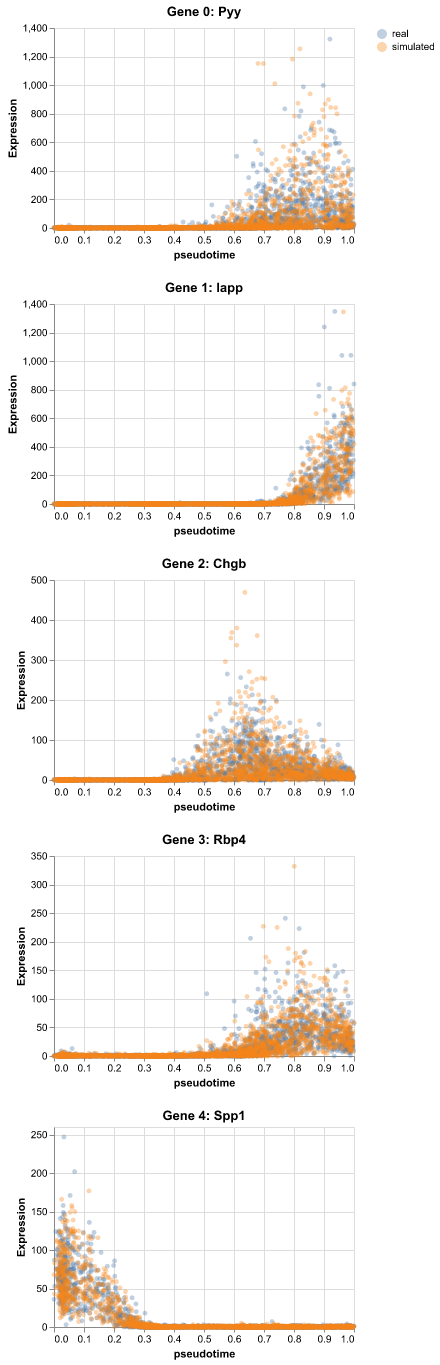

In [8]:
plot_sampled_expression_by_covariate(
    sim, 
    example_sce, 
    num_genes=5, 
    covariate="pseudotime"
)

The simulated data is also well mixed with the real data expression.

# Poisson

In addition to Negative Binomial distribution, we can use the Poisson distribution for non-negative integer counts. It is a useful baseline, but it may underestimate variability in overdispersed single-cell data; in that case, we would prefer NB.

To demonstrate, we will use the same example dataset and the same `mean_formula` as we used for `NegBinCopula`. Since Poisson distribution assumes the gene variances to be equal to the gene means, it does not alow additional flexibility in the variance modeling, thus we don't have a `disperson_formula` for the `PoissonCopula`.

In [9]:
from scdesigner.simulators import PoissonCopula

sim = PoissonCopula(
    mean_formula = "~ bs(pseudotime, df=10)",
    copula_formula = "~ 1"
)
sim.fit(example_sce)
sim

Epoch 161/500, Loss: 2.8992, Val Loss: 2.9590


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 15.78it/s]


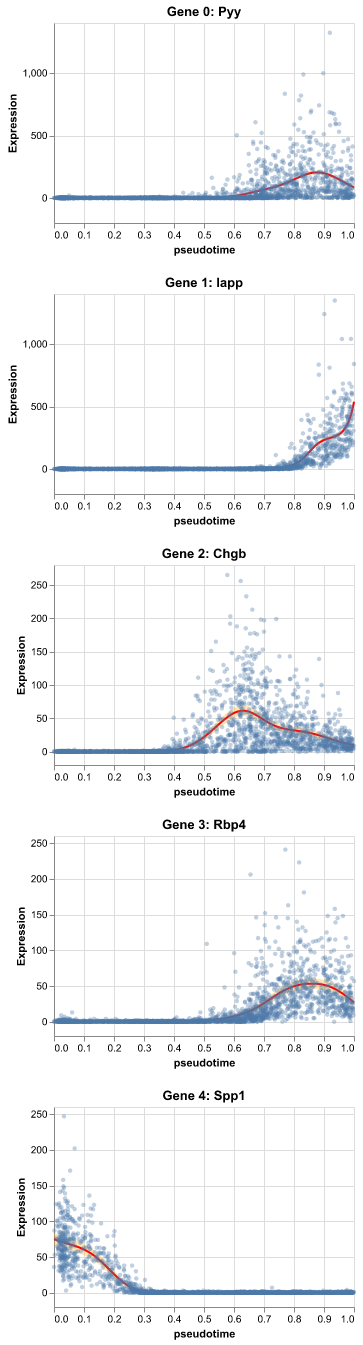

In [10]:
# Visualize Poisson model
plot_fit_by_covariate(
    sim, 
    example_sce, 
    distribution="poisson",
    covariate="pseudotime",
    num_genes=5
)

We can see that in this case, the means are well fitted for the genes, but the variances fail to capture the variability in the expressions. This suggests that we may want a model that can capture the extra dispersion, and using a NB model is more appropriate.

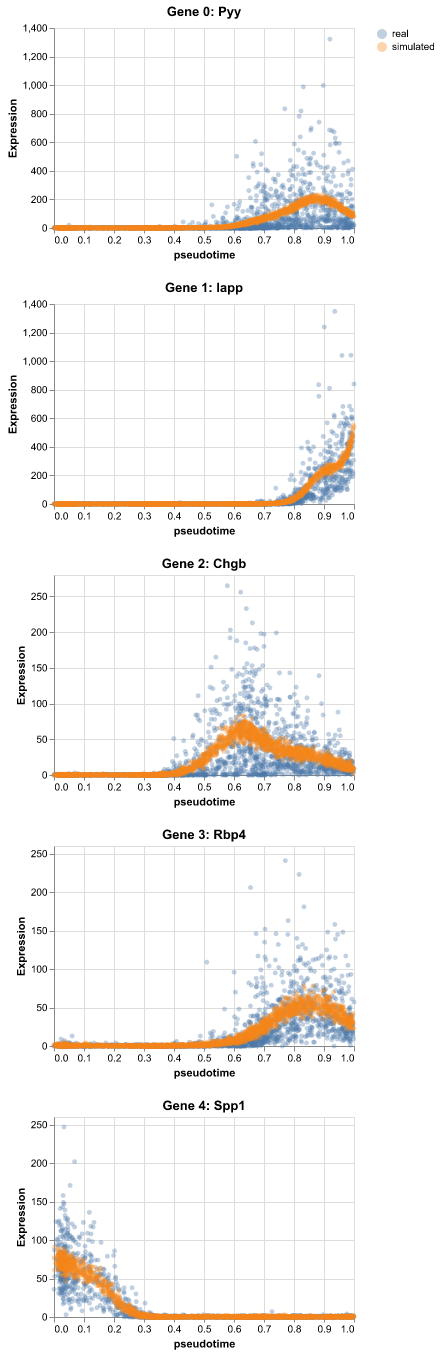

In [11]:
# Compare real vs simulated data
plot_sampled_expression_by_covariate(
    sim, 
    example_sce, 
    covariate="pseudotime",
    num_genes=5
)

The simulated data is also unable to reflect the real gene expressions.

# Zero-Inflated Poisson

Sometimes, an excess of zeros can arise even in the absence of overdispersion (in which case a NB model can be more useful). In cases where the raw count data has more zeros than a plain Poisson model can explain, but the non-zero count component is otherwise Poisson-like, we can use Zero-Inflated Poisson (ZIP) model to account for the additional zero-inflation information.

In this example, we will use the scATAC-seq data of human PBMC, which is known to have a high proportion of zeros.

In [12]:
from scdesigner.simulators import ZeroInflatedPoissonCopula
from scdesigner.datasets import granja_atac

example_sce = granja_atac()
example_sce

AnnData object with n_obs × n_vars = 7034 × 1133
    obs: 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'passed_filters', 'cell_id', 'is__cell_barcode', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'peaks_snn_res.0.8', 'seurat_clusters', 'ident', 'cell_type'
    obsm: 'LSI', 'UMAP'

In [13]:
sim = PoissonCopula(
    mean_formula = "~ cell_type",
    copula_formula = "~ 1"
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 189/500, Loss: 0.3775, Val Loss: 0.3823


Estimating copula correlation: 100%|██████████| 7/7 [00:02<00:00,  3.39it/s]


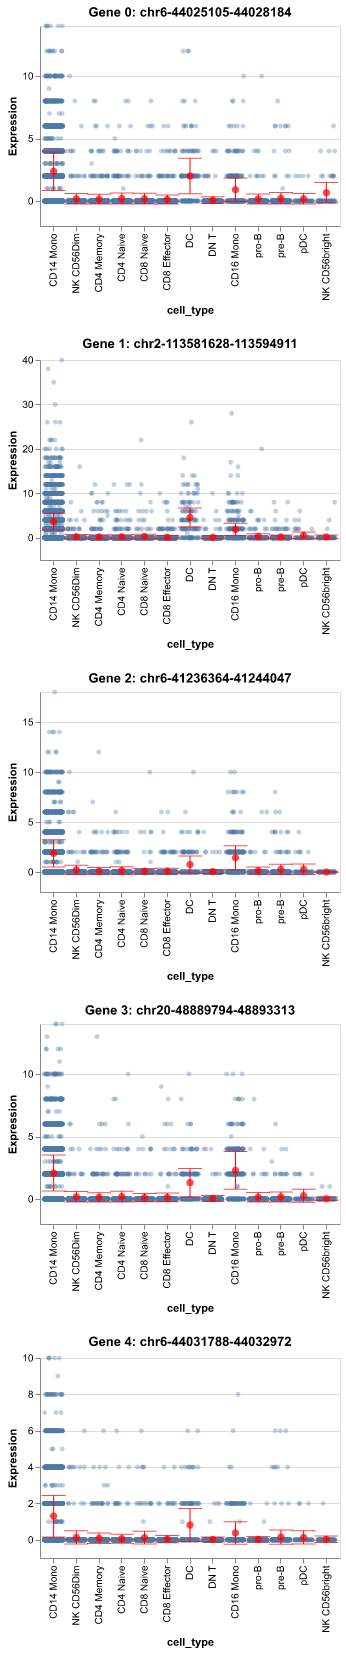

In [14]:
plot_fit_by_covariate(
    sim, 
    example_sce, 
    distribution="poisson",
    covariate="cell_type",
    num_genes=5
)

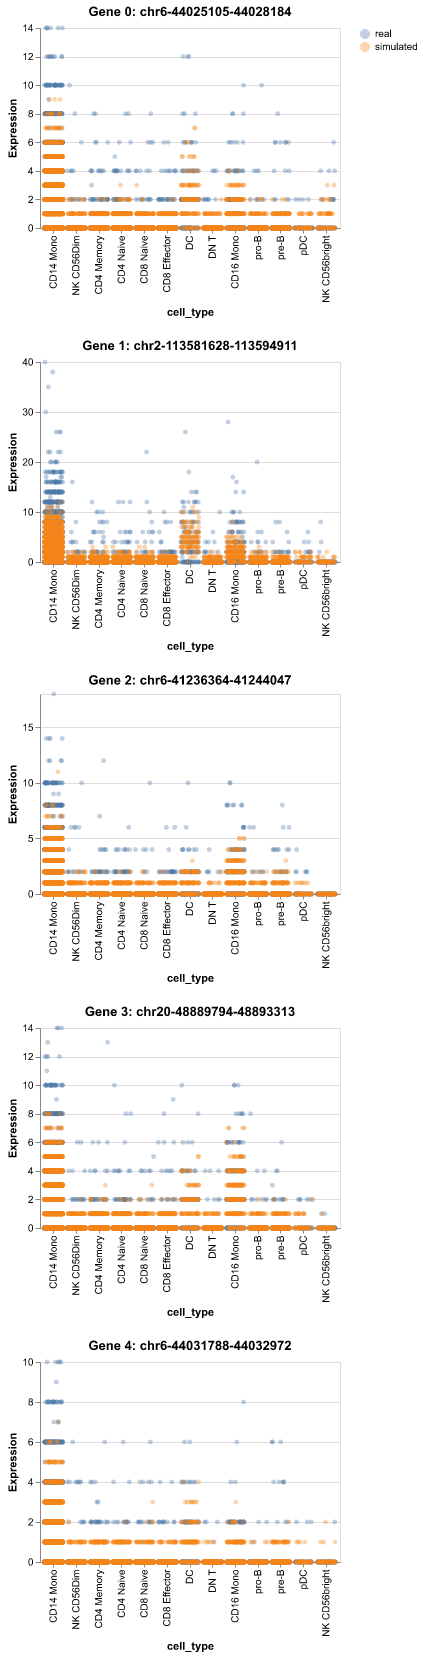

In [15]:
plot_sampled_expression_by_covariate(
    sim, 
    example_sce, 
    covariate="cell_type",
    num_genes=5
)

First fitting the data using simply Poisson distribution suggests that the model, affected by the excessive zeros in the dataset, underestimates the distribution parameters. As a result, the simulation model fails to reproduce the more expressed gene samples. 

In this case, we can turn to `ZeroInflatedPoissonCopula`, which allows an additional `zero_inflation` parameter.

In [16]:
sim = ZeroInflatedPoissonCopula(
    mean_formula = "~ cell_type",
    zero_inflation_formula = "~ cell_type",
    copula_formula = "~ 1"
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 500/500, Loss: 0.2745, Val Loss: 0.2812


Estimating copula correlation: 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]


Similar to `mean` and `dispersion` parameters, We can access the fitted coefficients of the `zero_inflation` parameter using `sim.marginal.parameters`.

In [17]:
sim.marginal.parameters['zero_inflation']

,chr6-44025105-44028184,chr2-113581628-113594911,chr6-41236364-41244047,chr20-48889794-48893313,chr6-44031788-44032972,chr20-1923912-1928154,chr15-93346770-93347989,chr2-113596703-113597906,chr3-46130424-46132103,chr19-47891861-47893634,...,chr8-21336556-21336818,chr4-25987003-25987275,chr2-8726063-8726568,chr1-53758476-53758638,chr4-785863-787006,chr16-58459697-58460545,chr16-67973505-67974483,chr1-222112920-222113382,chr2-233174300-233175622,chr3-13015237-13015864
Intercept,-0.736033,-0.823559,-0.288491,-0.612632,0.023922,-0.168845,-0.124682,-0.021827,-0.002641,-0.026368,...,-0.514774,-0.979563,4.067638,-0.471533,-0.797027,2.572020,-0.263455,-1.149085,-1.159219,0.217634
cell_type[T.CD4 Memory],3.637553,3.952273,3.487314,3.658535,3.266497,3.526539,3.003359,3.495191,3.053018,3.288145,...,5.313619,13.754531,0.047356,13.808329,3.465943,1.977395,3.315864,13.909288,4.250864,3.610573
cell_type[T.CD8 Effector],3.699995,3.857640,3.472897,3.938473,3.910841,3.545830,3.419561,3.670452,3.807677,3.521417,...,-4.007427,13.688678,0.566287,-5.395663,3.800574,1.846155,3.210343,6.719538,3.542901,2.727349
cell_type[T.CD4 Naive],3.420079,3.681332,2.925989,3.327256,3.634970,3.051765,3.229184,3.274522,2.731406,3.070937,...,4.467382,13.729465,0.615762,-4.731854,3.565114,2.003912,2.642751,13.890618,4.604974,3.919168
cell_type[T.DN T],4.208298,4.259256,4.240974,4.476073,4.140140,3.692303,4.028495,3.887124,3.670247,3.861383,...,13.400899,13.698769,0.950333,13.750221,5.093314,3.144507,2.986312,7.000940,3.763011,-2.620796
cell_type[T.CD8 Naive],3.517964,3.756670,3.926525,3.797214,2.991641,3.402603,3.385998,3.152104,2.979276,3.184962,...,-3.118875,13.708771,-2.923163,-4.000638,3.447458,2.141842,3.580070,13.876111,4.140260,-2.662350
cell_type[T.NK CD56Dim],3.547505,3.503773,3.042940,3.252526,3.029569,3.592264,2.786236,3.613778,3.214007,2.928204,...,13.401217,13.699619,2.900008,-3.447307,-2.147807,0.605145,3.605541,6.660487,3.006127,2.932924
cell_type[T.pre-B],3.523079,3.494737,2.840116,3.250609,3.206766,2.517626,3.622992,2.650012,3.359496,2.788152,...,13.389613,4.411629,-0.209157,4.953433,5.075444,1.180686,3.205282,2.940823,5.893968,3.332326
cell_type[T.CD16 Mono],1.600245,1.120748,0.373510,-0.268319,1.439630,0.393939,0.737365,0.744562,0.545521,0.161852,...,13.350399,-3.097599,10.369815,13.703397,5.251646,-0.693244,12.589584,-2.881618,6.367568,4.023098
cell_type[T.pro-B],3.628582,3.363441,3.286902,3.625065,3.648149,2.867438,3.251927,2.809846,2.588222,3.532418,...,3.708404,3.290912,1.409136,5.512733,4.681363,0.682371,3.242285,3.130995,6.532319,2.559474


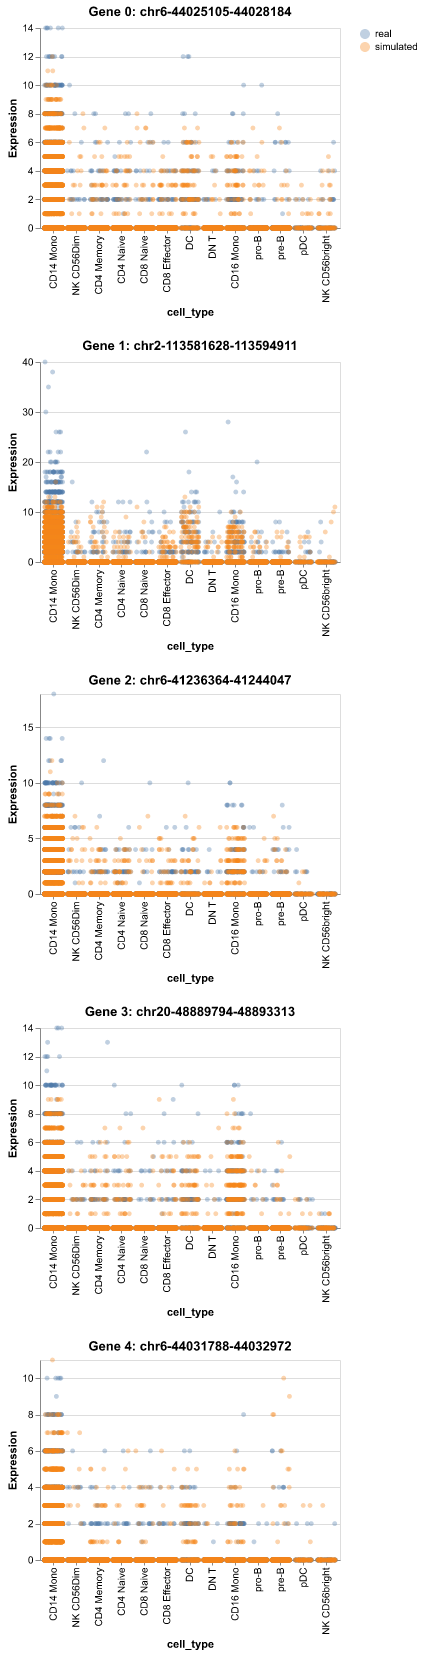

In [18]:
plot_sampled_expression_by_covariate(
    sim, 
    example_sce, 
    covariate="cell_type",
    num_genes=5
)

The model is now more robust to the excess of zeros and captures the expression distributions in the original data more truthfully.

# Zero-Inflated Negative Binomial

In some cases, the data can contain both an excess of zeros (zero-inflation) and an excess in the variability (overdispersion), in which case a zero-inflated Negative Binomial model may be appropriate.

In [19]:
from scdesigner.simulators import ZeroInflatedNegBinCopula

sim = ZeroInflatedNegBinCopula(
    mean_formula = "~ cell_type",
    zero_inflation_formula = "~ cell_type",
    copula_formula = "~ 1"
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 500/500, Loss: 0.2714, Val Loss: 0.2774


Estimating copula correlation: 100%|██████████| 7/7 [00:02<00:00,  3.34it/s]


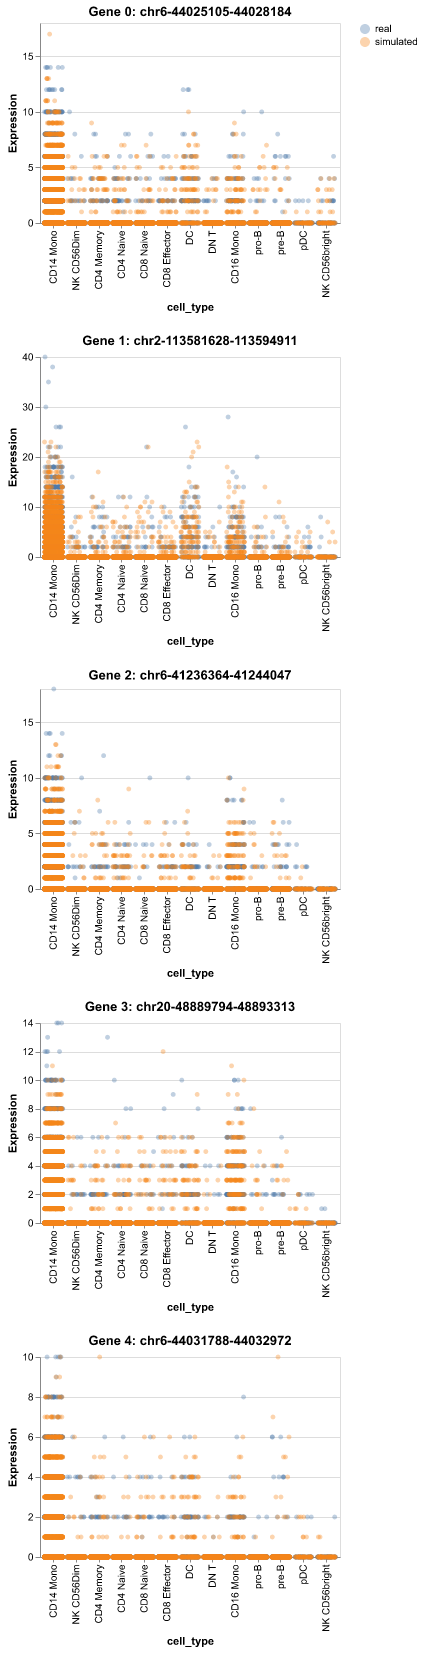

In [20]:
plot_sampled_expression_by_covariate(
    sim, 
    example_sce, 
    covariate="cell_type",
    num_genes=5
)

We can see the zero-inflated Negative Binomial model allows more variability in the `CD14 Mono` cell type, which was poorly simulated previously by the zero-inflated Poisson model.

# Bernoulli

We can use the Bernoulli distribution when the features are binary (0 or 1), such as detected/not detected, accessible/inaccessible, or methylated/unmethylated measurements. It models the probability of a positive outcome rather than the magnitude of a count.

In this example, we'll be using the human foreskin fibroblast reprogramming to iPS dataset sequenced under scGEM protocal.

In [21]:
from scdesigner.simulators import BernoulliCopula
from scdesigner.datasets import scgemmeth

example_sce = scgemmeth()
example_sce

AnnData object with n_obs × n_vars = 142 × 27
    obs: 'X1', 'X2', 'X3', 'X4', 'X5', 'cell_type', 'UMAP1_integrated', 'UMAP2_integrated'
    layers: 'counts'

In [22]:
sim = BernoulliCopula(
    mean_formula = "~ bs(X2, df=3)",
    copula_formula = "~ 1"
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 500/500, Loss: 0.4322, Val Loss: 0.4680


Estimating copula correlation: 100%|██████████| 1/1 [00:00<00:00, 46.50it/s]


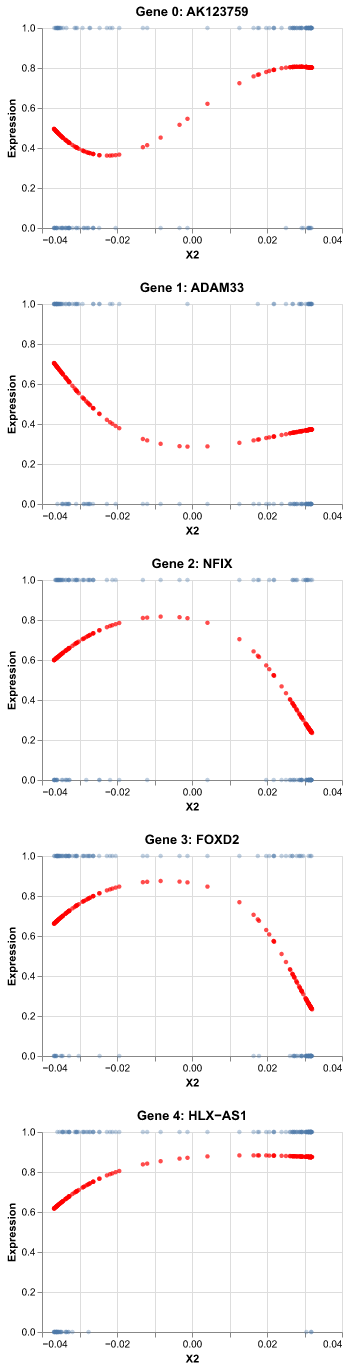

In [23]:
plot_fit_by_covariate(
    sim, 
    example_sce, 
    distribution="bernoulli",
    covariate="X2",
    num_genes=5
)

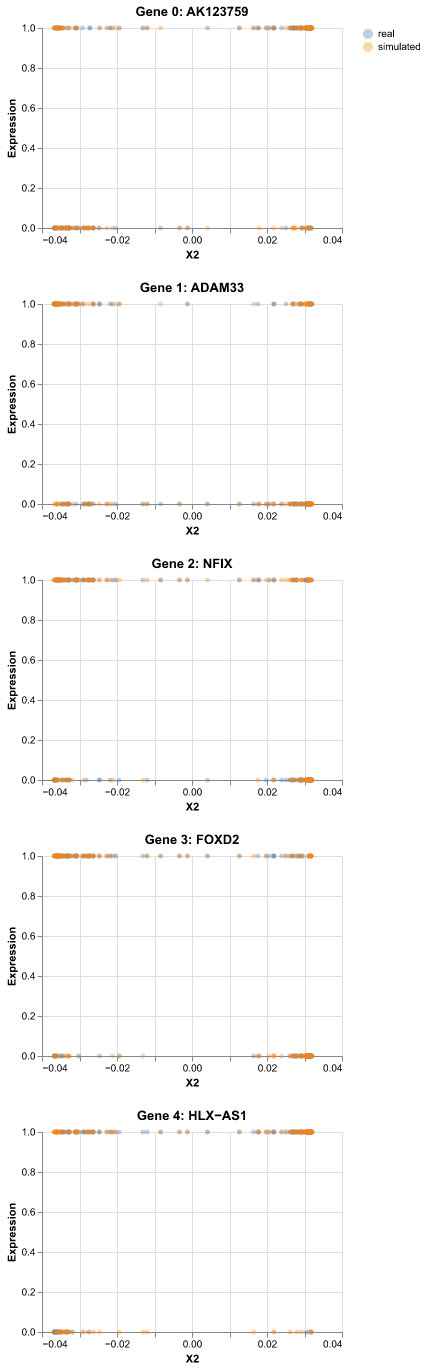

In [24]:
plot_sampled_expression_by_covariate(
    sim, 
    example_sce, 
    covariate="X2", 
    num_genes=5
)

# Gaussian and Zero-Inflated Gaussian

When the input matrix is continuous and normalized (such as a log-transformed count matrix), we can use the Gaussian distribution for model fitting. Gaussian model is generally not suitable for raw counts because it does not preserve discreteness or non-negativity.

We will again use the pancreas dataset we used in `NegBinCopula` and `PoissonCopula` examples as demonstration, but here we will first log-normalize the dataset to make the data suitable for the Gaussian model.

In [25]:
import scanpy as sc

gaussian_sce = pancreas().copy()
sc.pp.normalize_total(gaussian_sce, target_sum=1e4)
sc.pp.log1p(gaussian_sce)
gaussian_sce

AnnData object with n_obs × n_vars = 2087 × 100
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'cell_type', 'sizeFactor', 'pseudotime'
    var: 'highly_variable_genes'
    uns: 'X_name', 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'counts', 'cpm', 'logcounts', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [26]:
gaussian_sce.X.todense()

matrix([[7.63897487, 0.        , 7.45868832, ..., 3.05217358, 0.        ,
         0.        ],
        [3.28492349, 0.        , 3.95917148, ..., 3.28492349, 0.        ,
         5.19821294],
        [0.        , 3.5808491 , 5.80690489, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [7.0797814 , 0.        , 6.92132107, ..., 2.82273421, 0.        ,
         2.82273421],
        [0.        , 0.        , 6.75816222, ..., 3.40633479, 0.        ,
         3.40633479],
        [0.        , 0.        , 3.0814521 , ..., 4.83421728, 0.        ,
         4.14899155]])

The expression matrix now contains continuous data.

Epoch 10/500, Loss: 1.7007, Val Loss: 1.6822


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 11.53it/s]


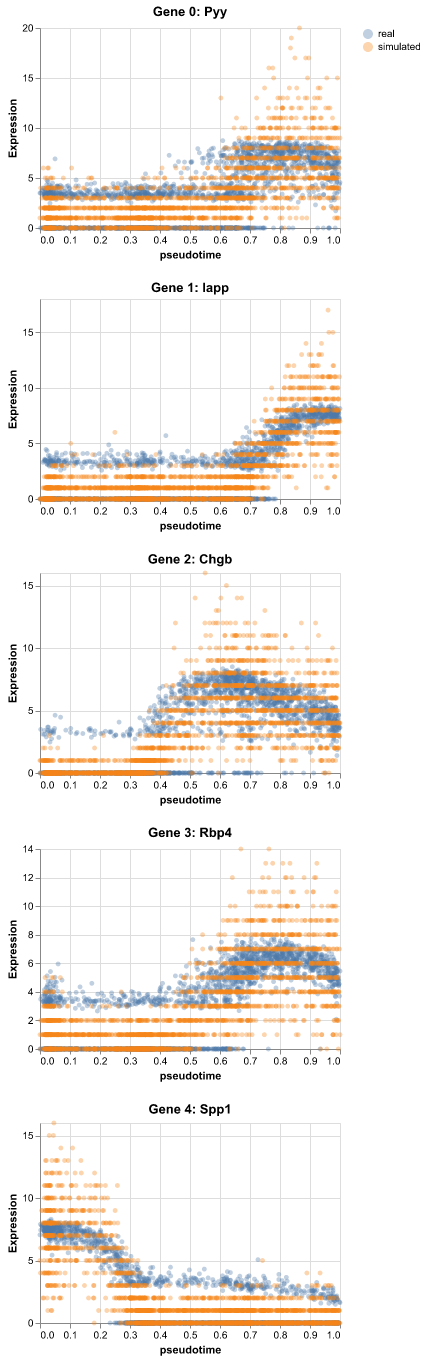

In [27]:
negbin_sim = NegBinCopula(
    mean_formula="~ bs(pseudotime, df=10)"
)
negbin_sim.fit(gaussian_sce)

plot_sampled_expression_by_covariate(
    negbin_sim, 
    gaussian_sce, 
    covariate="pseudotime",
    num_genes=5
)

Simply fitting the data with Negative Binomial models fails to capture the continuous property of the dataset.

Since the count matrix is no longer discrete, we can fit the model using `GaussianCopula`. It also contains a parameter to control for its variance, but unlike `NegBinCopula` which uses `dispersion_formula`, `GaussianCopula` now uses `sdev_formula`, and we can access its standard deviation coefficients using `sim.marginal.parameters['sdev']`.

In [28]:
from scdesigner.simulators import GaussianCopula

gaussian_sim = GaussianCopula(
    mean_formula = "~ bs(pseudotime, df=10)",
    sdev_formula = "~ bs(pseudotime, df=3)",
    copula_formula = "~ 1"
)
gaussian_sim.fit(gaussian_sce)

Epoch 500/500, Loss: 1.8413, Val Loss: 1.8363


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00,  9.21it/s]


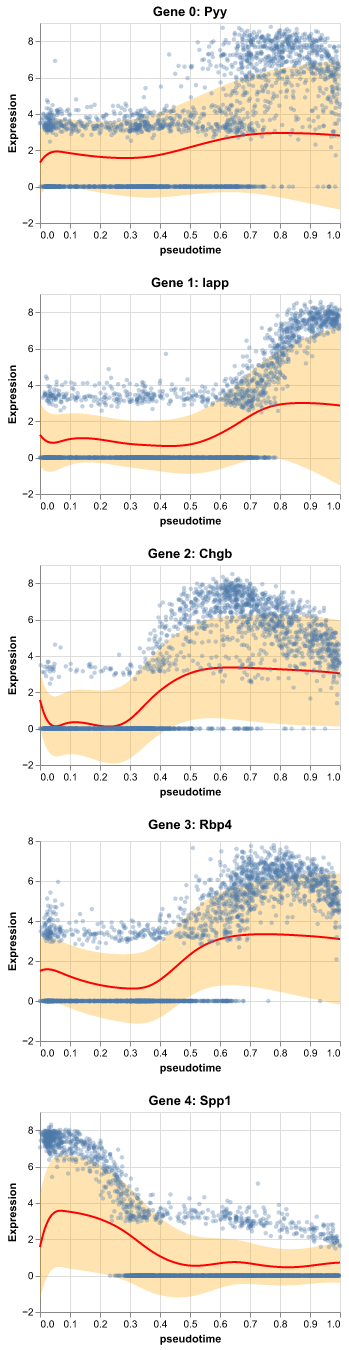

In [30]:
plot_fit_by_covariate(
    gaussian_sim, 
    gaussian_sce,
    distribution="gaussian",
    covariate="pseudotime",
    num_genes=5
)

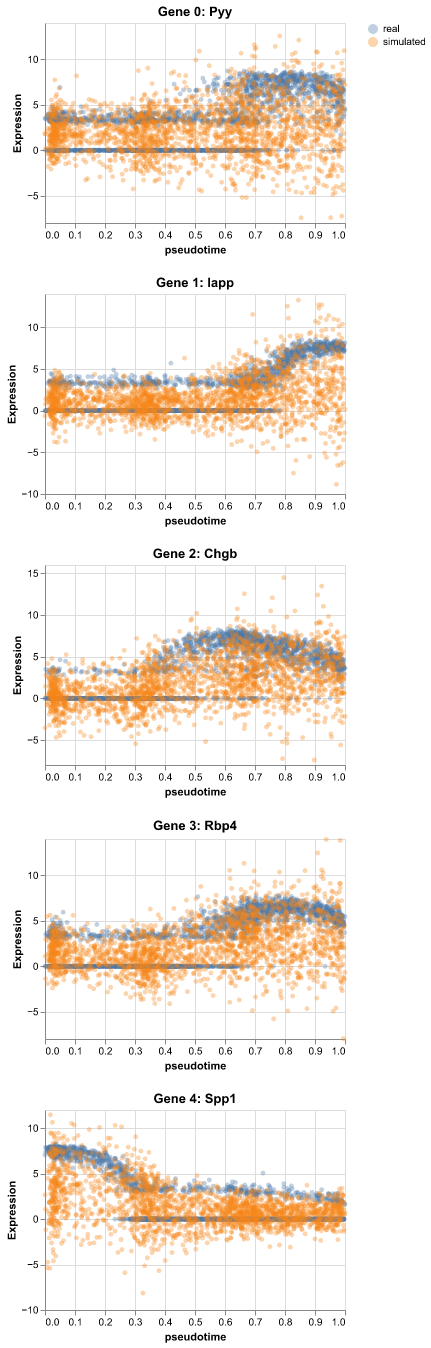

In [31]:
plot_sampled_expression_by_covariate(
    gaussian_sim, 
    gaussian_sce,
    covariate="pseudotime",
    num_genes=5
)

We can see that when fitting log-normalized count matrix with plain Gaussian distributions, the fitted means are pulled down by the exessive zeros in the expression, and the simulated data also fasely generate negative values. So a more natural approach would be to use the `ZeroInflatedTruncatedGaussianCopula`, which adds the `zero_inflation` parameter as in `ZeroInflatedPoissonCopula` and truncates the negative values to 0.

In [32]:
from scdesigner.simulators import ZeroInflatedTruncatedGaussianCopula

gaussian_sim = ZeroInflatedTruncatedGaussianCopula(
    mean_formula = "~ bs(pseudotime, df=10)",
    sdev_formula = "~ bs(pseudotime, df=3)",
    zero_inflation_formula = "~ pseudotime",
    copula_formula = "~ 1"
)
gaussian_sim.fit(gaussian_sce)

Epoch 500/500, Loss: 1.2501, Val Loss: 1.0797


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 10.94it/s]


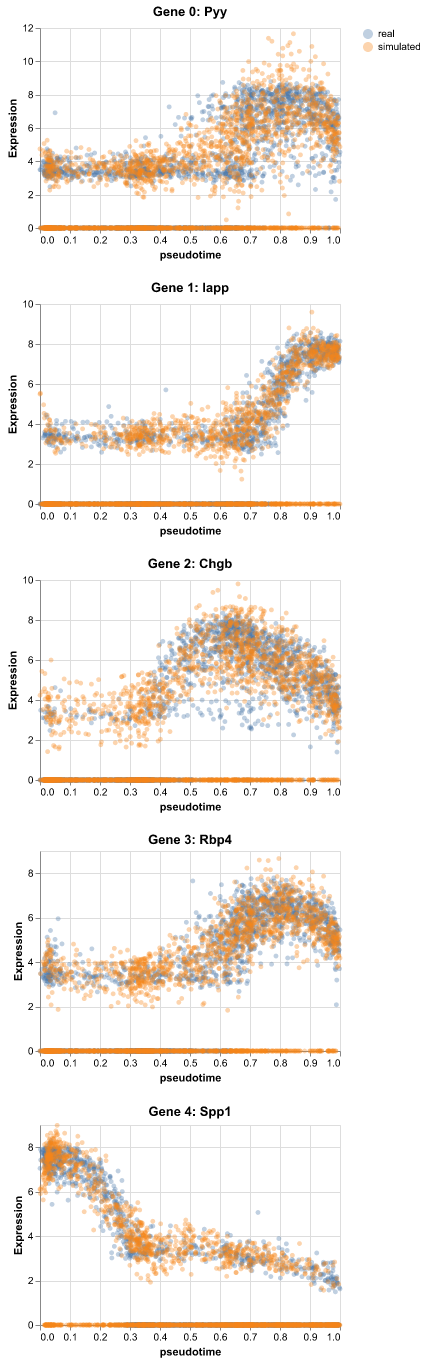

In [33]:
plot_sampled_expression_by_covariate(
    gaussian_sim, 
    gaussian_sce, 
    covariate="pseudotime",
    num_genes=5
)